# Structured Output

In langchain, structured output refers to the practive of having language models return responses in a well-defined data format (for example JSON), rather than free-form text.  

This makes the model output easier to parse & work programmatically.

### Need of Structured Output:
1. Data Extraction
2. API Building
3. AI Agents

- There are 2 type of models:
    1. LLMs which can generate structured output on there own - Use with_structured_output
    2. LLMs which cannot generate structured output - Use Output parsers

## with_strucutred_output
- It is used just before invoking the AI model
- At the time we call with_strucutred_output, we need to specify data format
- Data-Format:
    1. TypeDict
    2. Pydantic
    3. JSON Schema

### 1. TypeDict:
- It is a way to define a dictionary in python where you specify what keys & values should exist. It helps ensure that your dictionary follows a specific structure  
- This format does not validate data i.e. it will give the keys & values but type of the vales might be different

### 2. Pydantic:
- It is a data validation and parsig library for python.
- It ensures that the data you work with is correct, structured & type safe
- It has builtin validation like dat-type conversion, default value, validate emails, We can create custom validations

### 3. JSON Schema:
- It is used when your project consist of multiple languages like backend - Python, Frontend - JS
- Becoz JSON is universal understandable format.

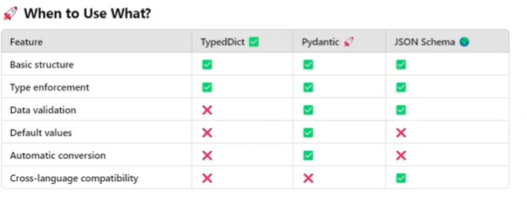

In [1]:
# TypeDict example with ChatGroq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Optional, Literal

load_dotenv()

model = ChatGroq(model="openai/gpt-oss-safeguard-20b", temperature=0.7)

# schema
class Review(TypedDict):
    key_themes: Annotated[list[str], "Write down all the key themes discussed in the review in a list"]
    summary: Annotated[str, "A brief summary of the review"]
    sentiment: Annotated[Literal["pos", "neg"], "Return sentiment of the review either negative, positive or neutral"]
    pros: Annotated[Optional[list[str]], "Write down all the pros inside a list"]
    cons: Annotated[Optional[list[str]], "Write down all the cons inside a list"]
    name: Annotated[Optional[str], "Write the name of the reviewer"]

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.
The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.
However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Divyang Jha
""")

print("--" * 70)
print("Key Themes:", result['key_themes'])
print("Summary:", result['summary'])
print("Sentiment:", result['sentiment'])
print("Pros:", result['pros'])
print("Cons:", result['cons'])
print("Reviewer Name:", result['name'])

d:\Repos\Agents\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--------------------------------------------------------------------------------------------------------------------------------------------
Key Themes: ['Processor performance', 'Battery life and charging', 'Camera quality and zoom', 'S-Pen integration', 'Device ergonomics', 'Software bloatware', 'Price']
Summary: The Samsung Galaxy S24 Ultra delivers top-tier performance, an impressive camera, and solid battery life, but its size, bloatware, and high price may deter some users.
Sentiment: pos
Pros: ['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful']
Cons: ['Heavy and bulky size makes one-handed use uncomfortable', 'Samsung’s One UI includes bloatware, adding unnecessary apps', 'High price tag ($1,300) is a hard pill to swallow']
Reviewer Name: Divyang Jha


In [2]:
# Pydantic example with ChatGroq
from dotenv import load_dotenv
from typing import Optional, Literal
from pydantic import BaseModel, Field

load_dotenv()

# schema
class Review(BaseModel):
    key_themes: list[str] = Field(description="Write down all the key themes discussed in the review in a list")
    summary: str = Field(description="A brief summary of the review")
    sentiment: Literal["pos", "neg"] = Field(description="Return sentiment of the review either negative, positive or neutral")
    pros: Optional[list[str]] = Field(default=None, description="Write down all the pros inside a list")
    cons: Optional[list[str]] = Field(default=None, description="Write down all the cons inside a list")
    name: Optional[str] = Field(default=None, description="Write the name of the reviewer")
    

structured_model = model.with_structured_output(Review)

result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.
The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.
However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Divyang Jha
""")

print("--" * 70)
print("Key Themes:", result.key_themes)
print("Summary:", result.summary)
print("Sentiment:", result.sentiment)
print("Pros:", result.pros)
print("Cons:", result.cons)
print("Reviewer Name:", result.name)

--------------------------------------------------------------------------------------------------------------------------------------------
Key Themes: ['Processor performance', 'Battery and charging', 'Camera quality and zoom', 'S-Pen integration', 'User interface bloatware', 'Price']
Summary: The Samsung Galaxy S24 Ultra delivers top-tier performance, a high‑resolution camera, and robust battery life, but its bulk, bloatware, and steep price dampen the experience.
Sentiment: pos
Pros: ['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful']
Cons: ['Weight and size make it uncomfortable for one-handed use', 'Samsung’s One UI still comes with bloatware', 'High price tag']
Reviewer Name: Divyang Jha


In [3]:
# Pydantic example
from dotenv import load_dotenv

load_dotenv()

# schema
json_schema = {
  "title": "Review",
  "type": "object",
  "properties": {
    "key_themes": {
      "type": "array",
      "items": {
        "type": "string"
      },
      "description": "Write down all the key themes discussed in the review in a list"
    },
    "summary": {
      "type": "string",
      "description": "A brief summary of the review"
    },
    "sentiment": {
      "type": "string",
      "enum": ["pos", "neg"],
      "description": "Return sentiment of the review either negative, positive or neutral"
    },
    "pros": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the pros inside a list"
    },
    "cons": {
      "type": ["array", "null"],
      "items": {
        "type": "string"
      },
      "description": "Write down all the cons inside a list"
    },
    "name": {
      "type": ["string", "null"],
      "description": "Write the name of the reviewer"
    }
  },
  "required": ["key_themes", "summary", "sentiment"]
}

structured_model = model.with_structured_output(json_schema)
result = structured_model.invoke("""I recently upgraded to the Samsung Galaxy S24 Ultra, and I must say, it’s an absolute powerhouse! The Snapdragon 8 Gen 3 processor makes everything lightning fast—whether I’m gaming, multitasking, or editing photos. The 5000mAh battery easily lasts a full day even with heavy use, and the 45W fast charging is a lifesaver.
The S-Pen integration is a great touch for note-taking and quick sketches, though I don't use it often. What really blew me away is the 200MP camera—the night mode is stunning, capturing crisp, vibrant images even in low light. Zooming up to 100x actually works well for distant objects, but anything beyond 30x loses quality.
However, the weight and size make it a bit uncomfortable for one-handed use. Also, Samsung’s One UI still comes with bloatware—why do I need five different Samsung apps for things Google already provides? The $1,300 price tag is also a hard pill to swallow.

Pros:
Insanely powerful processor (great for gaming and productivity)
Stunning 200MP camera with incredible zoom capabilities
Long battery life with fast charging
S-Pen support is unique and useful
                                 
Review by Divyang Jha
""")

print("--" * 70)
print("Key Themes:", result['key_themes'])
print("Summary:", result['summary'])
print("Sentiment:", result['sentiment'])
print("Pros:", result['pros'])
print("Cons:", result['cons'])
print("Reviewer Name:", result['name'])

--------------------------------------------------------------------------------------------------------------------------------------------
Key Themes: ['Performance', 'Battery life', 'Camera quality', 'S-Pen integration', 'Device ergonomics', 'Software bloat', 'Price']
Summary: The reviewer highlights the Galaxy S24 Ultra’s powerful processor, excellent camera, long battery life, and S‑Pen support while noting its bulk, software bloat, and steep price as key drawbacks.
Sentiment: pos
Pros: ['Insanely powerful processor (great for gaming and productivity)', 'Stunning 200MP camera with incredible zoom capabilities', 'Long battery life with fast charging', 'S-Pen support is unique and useful']
Cons: ['Heavy size and weight make one-handed use uncomfortable', 'Bloatware in One UI with unnecessary Samsung apps', 'High price tag ($1,300)', 'Camera quality degrades beyond 30x zoom']
Reviewer Name: Divyang Jha


# Output Parsers
- Output parsers in Langchain help convert raw LLM responses into structured formats like JSON, CSV, Pydantic models & more.
- They ensure consistency, validation, & ease of use in applications
- Output parsers can work with both models:
    1. LLMs which can generate structured output on there own - Use with_structured_output
    2. LLMs which cannot generate structured output - Use Output parsers  

In Langchain there are lots of output parsers, but there are 4 most commonly used parsers:
1. String Output Parsers
2. JSON Output Parsers
3. Structured Output Parsers
4. Pydantic Output Parsers

### 1. String Output Parsers:
- It is the simplest output parser in LangChain. It is used to parse the output of a language model & return it as plain string.
- We use this parser usually with Chains

### 2. JSON Output Parsers:
- Used to convert LLM output into valid JSON format. Ensures the response follows a structured key-value format
- Requires giving format instructions to the model
- Useful when you need machine-readable structured data
- Cannot Enforce Schema - LLM decides the schema

### 3. Structured Output Parsers:
- Used to define custom structured schemas (using response schemas). Helps enforce specific fields and formats in output
- More flexible than JSON parser for guided structure generation
- Works well when you want controlled but not strict validation

### 4. Pydantic Output Parsers:
- Uses Pydantic models to parse and validate LLM output. Ensures type safety and strict validation
- Automatically converts output into Python objects
- Best for production use where data reliability is critical

In [4]:
# String output parsing example
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

load_dotenv()

# 1st prompt -> detailed report
template1 = PromptTemplate(
    template='Write a detailed report on {topic}',
    input_variables=['topic']
)

# 2nd prompt -> summary
template2 = PromptTemplate(
    template='Write a 5 line summary on the following text. /n {text}',
    input_variables=['text']
)

parser = StrOutputParser()

chain = template1 | model | parser | template2 | model | parser

result = chain.invoke({'topic':'black hole'})

print(result)


1. Black holes, formed from stellar collapse, mergers, or direct gas collapse, span from primordial micro‑mass objects to ultra‑massive super‑galactic cores.  
2. Their defining feature is the event horizon (Schwarzschild radius) and, for rotating cases, an ergosphere that allows energy extraction.  
3. Observational evidence includes stellar dynamics (e.g., Sgr A*), X‑ray binaries, AGN signatures, gravitational‑wave detections, and the EHT’s M87* image.  
4. Key theoretical concepts cover general‑relativistic metrics (Schwarzschild, Kerr, Reissner–Nordström), Hawking radiation, and the cosmic censorship conjecture.  
5. Outstanding questions—information paradox, primordial BH dark‑matter role, seed mechanisms for super‑massive BHs, and intermediate‑mass BH detection—drive future multi‑messenger research.


In [5]:
# JSON output parsing example
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

load_dotenv()

parser = JsonOutputParser()
template = PromptTemplate(
    template='Give me 5 facts about {topic} \n {format_instruction}',
    input_variables=['topic'],
    partial_variables={'format_instruction': parser.get_format_instructions()}
)

chain = template | model | parser
result = chain.invoke({'topic':'black hole'})

print(result)


{'facts': ["A black hole's gravity is so strong that not even light can escape once it crosses the event horizon.", 'The size of a black hole is defined by its Schwarzschild radius, which is proportional to its mass.', 'Black holes can spin, and the amount of spin affects the shape of spacetime around them, creating a region called the ergosphere.', "The first image of a black hole's event horizon was captured by the Event Horizon Telescope in 2019, showing the silhouette of the supermassive black hole in M87.", 'Despite their name, black holes are not perfect vacuum; they can emit Hawking radiation, a theoretical process that causes them to lose mass over time.']}


In [6]:
# Pydantic output parsing example
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

load_dotenv()

class Person(BaseModel):
    name: str = Field(description='Name of the person')
    age: int = Field(gt=18, description='Age of the person')
    city: str = Field(description='Name of the city the person belongs to')

parser = PydanticOutputParser(pydantic_object=Person)

template = PromptTemplate(
    template='Generate the name, age and city of a fictional {place} person \n {format_instruction}',
    input_variables=['place'],
    partial_variables={'format_instruction':parser.get_format_instructions()}
)

chain = template | model | parser
final_result = chain.invoke({'place':'sri lankan'})

print(final_result)

name='Kavindu Perera' age=27 city='Kandy'


In [7]:
# from dotenv import load_dotenv
# from langchain_core.prompts import PromptTemplate
# from langchain.output_parsers import StructuredOutputParser, ResponseSchema

# load_dotenv()

# schema = [
#     ResponseSchema(name='fact_1', description='Fact 1 about the topic'),
#     ResponseSchema(name='fact_2', description='Fact 2 about the topic'),
#     ResponseSchema(name='fact_3', description='Fact 3 about the topic'),
# ]

# parser = StructuredOutputParser.from_response_schemas(schema)

# template = PromptTemplate(
#     template='Give 3 fact about {topic} \n {format_instruction}',
#     input_variables=['topic'],
#     partial_variables={'format_instruction':parser.get_format_instructions()}
# )

# chain = template | model | parser

# result = chain.invoke({'topic':'black hole'})

# print(result)